In [1]:
from google.colab import files
uploaded = files.upload()

Saving laptop_price.csv to laptop_price.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("laptop_price.csv", encoding="latin1")
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [23]:
df.drop("laptop_ID", axis=1, inplace=True)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1303 non-null   int64  
 1   Product           1303 non-null   int64  
 2   TypeName          1303 non-null   int64  
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   int64  
 5   Cpu               1303 non-null   int64  
 6   Ram               1303 non-null   int64  
 7   Memory            1303 non-null   int64  
 8   Gpu               1303 non-null   int64  
 9   OpSys             1303 non-null   int64  
 10  Weight            1303 non-null   int64  
 11  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(10)
memory usage: 122.3 KB


In [25]:
df.isnull().sum()

,0
Company,0
Product,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0
OpSys,0


In [26]:
df.shape

(1303, 12)

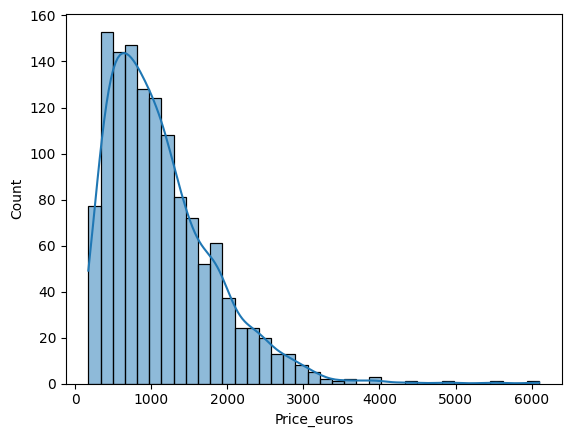

In [27]:
sns.histplot(df['Price_euros'], kde=True)
plt.show()

In [28]:
df.drop(columns=["Unnamed: 0"], errors="ignore", inplace=True)

In [29]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [30]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,300,4,13.3,23,65,8,4,58,8,38,1339.69
1,1,301,4,13.3,1,63,8,2,51,8,35,898.94
2,7,50,3,15.6,8,74,8,16,53,4,74,575.00
3,1,300,4,15.4,25,85,1,29,9,8,71,2537.45
4,1,300,4,13.3,23,67,8,16,59,8,38,1803.60


In [31]:
X = df.drop("Price_euros", axis=1)
y = df["Price_euros"]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

RandomForestRegressor()

In [34]:
predictions = model.predict(X_test)

In [35]:
from sklearn.metrics import r2_score

pred = model.predict(X_test)

r2_score(y_test, pred)

0.8436018406023029

In [37]:
X.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu',
       'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight'],
      dtype='object')

In [38]:
import joblib

joblib.dump(model, "laptop_price_model.pkl")

['laptop_price_model.pkl']

In [39]:
files.download("laptop_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>